# Linear Regression from Scratch  
### Housing Prices Dataset

This notebook implements Linear Regression manually without using ML libraries
such as sklearn or statsmodels. The objective is to understand how Linear
Regression works internally.

Objective:
To understand how Linear Regression works internally by building:

• Data preprocessing pipeline  
• Prediction function  
• Loss function (MSE)  
• Gradient Descent training  
• Model evaluation  

Dataset:
Housing Prices Dataset (Kaggle)


Data Loading & Preprocessing

In [1]:
#Import Libraries

!pip install kagglehub

# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# File handling
import os

# Dataset download helper
import kagglehub


Dataset is loaded using KaggleHub to ensure reproducibility.


In [2]:
# Download dataset directly from KaggleHub
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

# Display dataset location
print("Dataset path:", path)


100%|██████████| 4.63k/4.63k [00:00<00:00, 7.03MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1


## Part 1 — Data Understanding

Before model construction, it is essential to inspect:

• Dataset structure  
• Data types  
• Statistical distribution  

This ensures appropriate preprocessing decisions.


In [4]:
# List files inside dataset directory
files = os.listdir(path)
print("Files in dataset:", files)

# Load Housing.csv into pandas DataFrame
df = pd.read_csv(os.path.join(path, "Housing.csv"))

# Preview first rows
df.head()


Files in dataset: ['Housing.csv']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
# Dataset structure overview
df.info()

# Statistical summary
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Handling Missing Values

Missing data can negatively affect:

• Gradient calculations  
• Loss computation  
• Model stability  

Rows containing missing values are removed to maintain numerical integrity.


In [6]:
def handle_missing(df):
    """
    Removes rows containing missing values.

    Why:
    Missing values can distort gradient computation and loss calculation.
    """
    return df.dropna()

df = handle_missing(df)


## Encoding Categorical Variables

Linear Regression requires numeric input features.

Categorical variables are converted into dummy variables using one-hot encoding,
allowing the model to interpret discrete categories mathematically.


In [7]:
def encode_categorical(df):
    """
    Converts categorical columns into numeric dummy variables.

    Why:
    Linear Regression requires purely numeric inputs.
    """
    return pd.get_dummies(df, drop_first=True)

df = encode_categorical(df)

df.head()


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [8]:
def split_features_target(df, target_column):
    """
    Separates independent variables (X) and dependent variable (y).
    """
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    return X, y

# Target = price
X, y = split_features_target(df, "price")


## Train–Test Split

The dataset is divided into:

• Training set → Used for learning parameters  
• Test set → Used strictly for evaluation  

This prevents biased performance estimates.


In [9]:
def train_test_split(X, y, test_ratio=0.2):
    """
    Splits dataset into training and testing subsets.

    Why:
    Ensures unbiased evaluation on unseen data.
    """
    split_index = int(len(X) * (1 - test_ratio))

    X_train = X[:split_index]
    X_test = X[split_index:]
    y_train = y[:split_index]
    y_test = y[split_index:]

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(X, y)


## Feature Scaling (Critical Step)

Features often exist on different scales.

Without scaling:

• Gradients may become unstable  
• Convergence may slow down  
• Large-scale features may dominate learning  

Scaling is performed using TRAINING DATA statistics only to prevent
information leakage.


In [10]:
def scale_features(X_train, X_test):
    """
    Standardizes features using TRAINING DATA statistics only.

    Why critical:
    Using test data statistics introduces information leakage.
    """
    mean = X_train.mean()
    std = X_train.std()

    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std

    return X_train_scaled, X_test_scaled

X_train, X_test = scale_features(X_train, X_test)


In [11]:
# Convert pandas DataFrames/Series → NumPy arrays
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values


## Part 2 — Linear Regression Model

Linear Regression predicts the target variable using:

ŷ = Xw + b

Where:

• X → Feature matrix  
• w → Weight (coefficient) vector  
• b → Bias (intercept) term  

The prediction function computes this linear combination.


In [12]:
def predict(X, weights, bias):
    """
    Computes predicted values using Linear Regression equation:

        ŷ = Xw + b

    X       → Feature matrix
    weights → Coefficient vector
    bias    → Constant offset
    """
    return np.dot(X, weights) + bias


## Loss Function — Mean Squared Error (MSE)

MSE measures the average squared difference between:

• True values  
• Predicted values  

Why MSE?

• Differentiable → Enables gradient computation  
• Penalizes large errors strongly  
• Standard choice for regression problems


In [21]:

def mse_loss(y_true, y_pred):
    """
    Mean Squared Error (MSE)

    Measures average squared difference between
    true values and predictions.

    Why MSE:
    • Smooth & differentiable
    • Penalizes large errors strongly
    """
    return np.mean((y_true - y_pred) ** 2)


##  Part -3  Training via Gradient Descent

Gradient Descent iteratively updates model parameters to minimize loss.

Training Loop:

1. Generate predictions  
2. Compute loss  
3. Calculate gradients  
4. Update weights & bias  
5. Repeat


In [14]:
def gradient_descent(X, y, weights, bias, learning_rate, epochs):
    """
    Optimizes weights & bias using Gradient Descent.

    Process:
    1. Predict outputs
    2. Compute gradients
    3. Update parameters
    4. Repeat

    learning_rate → Step size
    epochs        → Iterations
    """

    n = len(y)  # Number of samples
    loss_history = []

    for epoch in range(epochs):

        # Step 1 — Predictions
        y_pred = predict(X, weights, bias)

        # Step 2 — Compute Loss
        loss = mse_loss(y, y_pred)
        loss_history.append(loss)

        # Step 3 — Compute Gradients
        dw = (-2 / n) * np.dot(X.T, (y - y_pred))
        db = (-2 / n) * np.sum(y - y_pred)

        # Step 4 — Update Parameters
        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db

        # Print progress periodically
        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss}")

    return weights, bias, loss_history


### Feature Importance Insight

Each weight represents the influence of a feature on price prediction.

Interpretation:

• Larger magnitude → Stronger impact  
• Positive value → Direct relationship  
• Negative value → Inverse relationship  

This provides interpretability to the Linear Regression model.
# Display learned coefficients
weights


In [15]:
# Start with zero weights and bias
weights = np.zeros(X_train.shape[1])
bias = 0

# Train model
weights, bias, loss_history = gradient_descent(
    X_train,
    y_train,
    weights,
    bias,
    learning_rate=0.01,
    epochs=1000
)


Epoch 0 | Loss: 30871648921522.02
Epoch 100 | Loss: 1682610113067.482
Epoch 200 | Loss: 1192365522431.0105
Epoch 300 | Loss: 1183057994299.4941
Epoch 400 | Loss: 1182800766292.7793
Epoch 500 | Loss: 1182781556988.8025
Epoch 600 | Loss: 1182778713782.9163
Epoch 700 | Loss: 1182778219307.2742
Epoch 800 | Loss: 1182778130373.5664
Epoch 900 | Loss: 1182778114213.4417


## Part 4 — Model Evaluation

After training, performance is evaluated on the test dataset.

Metric Used:

Mean Squared Error (MSE)

Purpose:

Assess how well the model generalizes to unseen data.


In [16]:
def evaluate(X_test, y_test, weights, bias):
    """
    Evaluates model performance on test dataset.
    """
    y_pred = predict(X_test, weights, bias)
    mse = mse_loss(y_test, y_pred)
    return mse


In [17]:
test_mse = evaluate(X_test, y_test, weights, bias)

print("Final Test MSE:", test_mse)


Final Test MSE: 1048585623814.3662


### Prediction Analysis

Points closer to the diagonal indicate better predictions.

Dispersion reflects prediction errors and model limitations.


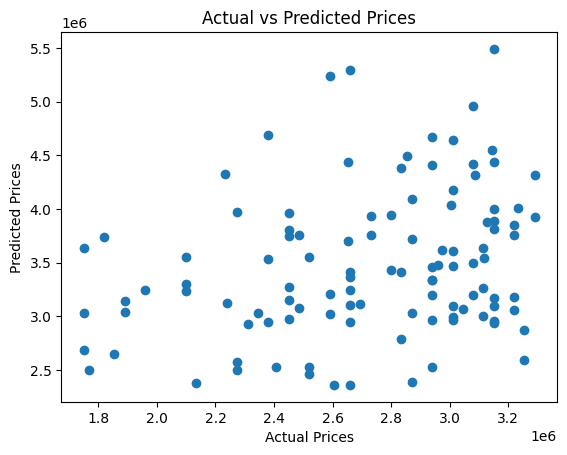

In [20]:
y_pred_test = predict(X_test, weights, bias)

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()


## Results & Observations

• Training loss decreased steadily, indicating successful gradient descent convergence  
• Model parameters adapted to minimize prediction error  
• Test MSE reflects generalization performance on unseen data  

This demonstrates how Linear Regression learns via iterative optimization.


• Training loss decreased steadily...


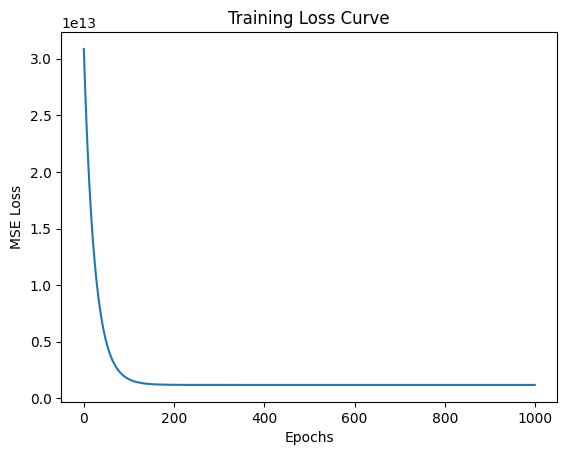

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()


### Loss Curve Interpretation

The steady decline in training loss indicates that Gradient Descent
successfully optimized the model parameters.

This confirms:

• Proper learning rate selection  
• Stable gradient updates  
• Convergence toward a minimum loss


## Model Limitations

While Linear Regression is simple and interpretable, it has limitations:

• Assumes linear relationships between variables  
• Sensitive to outliers  
• Cannot capture complex nonlinear patterns  
• Performance depends heavily on feature engineering  

Understanding these constraints is critical when selecting models.


## Conclusion

This notebook demonstrated how Linear Regression operates internally by
implementing prediction, loss computation, and Gradient Descent optimization
from scratch.

Key takeaway:

Understanding algorithm mechanics provides deeper intuition than relying solely
on library abstractions.
